[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-1/chain.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58238466-lesson-4-chain)

# Chain

## Review

We built a simple graph with nodes, normal edges, and conditional edges.

## Goals

Now, let's build up to a simple chain that combines 4 concepts.

* Using [chat messages](https://docs.langchain.com/oss/python/langchain/messages) as our graph state
* Using [chat models](https://docs.langchain.com/oss/python/integrations/chat) in graph nodes
* [Binding tools](https://docs.langchain.com/oss/python/langchain/models#tool-calling) to our chat model
* [Executing tool calls](https://docs.langchain.com/oss/python/langchain/models#tool-execution-loop) in graph nodes 

![Screenshot 2024-08-21 at 9.24.03 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dd607b08df5e1101_chain1.png)

In [1]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph

__name__ = "__main__"

## Messages

Chat models can use [messages](https://docs.langchain.com/oss/python/langchain/messages), which capture different roles within a conversation. 

LangChain supports various message types, including `HumanMessage`, `AIMessage`, `SystemMessage`, and `ToolMessage`. 

These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call. 

Let's create a list of messages. 

Each message can be supplied with a few things:

* `content` - content of the message
* `name` - optionally, a message author 
* `response_metadata` - optionally, a dict of metadata (e.g., often populated by model provider for `AIMessages`)

In [2]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about?", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about?
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


## Chat Models

Chat models use a sequence of messages as input and support message types, as discussed above.

There are [many](https://docs.langchain.com/oss/python/integrations/chat) to choose from! Let's work with OpenAI. 

Let's check that your `OPENAI_API_KEY` is set and, if not, you will be asked to enter it.

In [3]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


if "OPENAI_API_KEY" not in os.environ:
    _set_env("OPENAI_API_KEY")

if "OPEN_ROUTER_API_KEY" not in os.environ:
    _set_env("OPEN_ROUTER_API_KEY")


We can load a chat model and invoke it with out list of messages.

We can see that the result is an `AIMessage` with specific `response_metadata`.

In [6]:
from langchain_openai import ChatOpenAI
# llm = ChatOpenAI(model="gpt-4o")
llm = ChatOpenAI(
    api_key=os.environ["OPEN_ROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1",
    # model="openai/gpt-oss-120b:free",   # OpenAI: gpt-oss-120b (free)
                                           # Free Users with $10+ in credits
                                           # - 1,000 requests per day
                                           # - 20 requests per minute
    model="openai/gpt-oss-120b",           # OpenAI: gpt-oss-120b (paid)
                                           # $0.039/M input, $0.19/M output
    temperature=0,
    default_headers={
        "HTTP-Referer": "localhost",  # Optional. Site URL for rankings on openrouter.ai.
        "X-Title": "langchain-academy",  # Optional. Site title for rankings on openrouter.ai.
    },
    extra_body={
        "provider": {
            "sort": "latency",           # prioritize lowest latency providers
            "allow_fallbacks": True,     # fall back to others if unavailable
        }
    }
)
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [7]:
result

AIMessage(content='## The Top U.S. Spots for Seeing Orcas (Killer Whales)\n\n| Rank | Location | Why It’s Great | Best Time to Visit | Typical Tour Options |\n|------|----------|----------------|--------------------|----------------------|\n| **1** | **San Juan Islands, Washington** (especially Friday Harbor & the surrounding waters) | • Highest concentration of resident “Southern Resident” orcas year‑round.<br>• Calm, sheltered waters make sightings frequent and close.<br>• Rich marine ecosystem (salmon, seals) that draws the whales. | **April\u202f–\u202fOctober** – peak in late spring (May‑June) when salmon runs are strongest; also good in early fall. | • Day‑long wildlife cruises (30‑min to 3‑hour trips).<br>• Kayak tours (for the adventurous, with a guide and safety boat).<br>• Whale‑watching from shore at Lime Kiln Point State Park (“Whale Watch Hill”). |\n| **2** | **Northwest Passage, Alaska** (e.g., **Juneau**, **Glacier Bay**, **Sitka**, **Ketchikan**) | • Both resident and t

In [8]:
result.response_metadata

{'token_usage': {'completion_tokens': 2140,
  'prompt_tokens': 135,
  'total_tokens': 2275,
  'completion_tokens_details': {'accepted_prediction_tokens': None,
   'audio_tokens': 0,
   'reasoning_tokens': 68,
   'rejected_prediction_tokens': None},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0},
  'cost': 0.00130425,
  'is_byok': False,
  'cost_details': {'upstream_inference_cost': 0.00130425,
   'upstream_inference_prompt_cost': 2.025e-05,
   'upstream_inference_completions_cost': 0.001284}},
 'model_provider': 'openai',
 'model_name': 'openai/gpt-oss-120b',
 'system_fingerprint': 'fp_dc4ca88fa4',
 'id': 'gen-1770348258-esmfLFRenOs8PvYpbPjp',
 'finish_reason': 'stop',
 'logprobs': None}

## Tools

Tools are useful whenever you want a model to interact with external systems.

External systems (e.g., APIs) often require a particular input schema or payload, rather than natural language. 

When we bind an API, for example, as a tool we given the model awareness of the required input schema.

The model will choose to call a tool based upon the natural language input from the user. 

And, it will return an output that adheres to the tool's schema. 

[Many LLM providers support tool calling](https://docs.langchain.com/oss/python/integrations/chat) and [tool calling interface](https://blog.langchain.com/improving-core-tool-interfaces-and-docs-in-langchain/) in LangChain is simple. 
 
You can simply pass any Python `function` into `ChatModel.bind_tools(function)`.

![Screenshot 2024-08-19 at 7.46.28 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dc1c17a7a57f9960_chain2.png)

Let's showcase a simple example of tool calling!
 
The `multiply` function is our tool.

In [9]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int

    >>> multiply(2, 3)
    6
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

import doctest
doctest.testmod(verbose=True)
doctest.run_docstring_examples(multiply, globals(), verbose=True, name="multiply")

Trying:
    multiply(2, 3)
Expecting:
    6
ok
2 items had no tests:
    __main__
    __main__._set_env
1 item passed all tests:
   1 test in __main__.multiply
1 test in 3 items.
1 passed.
Test passed.
Finding tests in multiply
Trying:
    multiply(2, 3)
Expecting:
    6
ok


If we pass an input - e.g., `"What is 2 multiplied by 3"` - we see a tool call returned. 

The tool call has specific arguments that match the input schema of our function along with the name of the function to call.

```
{'arguments': '{"a":2,"b":3}', 'name': 'multiply'}
```

In [10]:
llm_invocation = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])
llm_invocation

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 142, 'total_tokens': 217, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 38, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'cost': 5.17e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 5.17e-05, 'upstream_inference_prompt_cost': 1.42e-05, 'upstream_inference_completions_cost': 3.75e-05}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': None, 'id': 'gen-1770348302-fqAy6PH7WMJssQZXSo6R', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c30fb-5121-7c12-98a4-fc8a02c0369a-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'chatcmpl-tool-55e9dd6525f7479583192445696f2e49', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 142, 'o

In [11]:
llm_invocation.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'chatcmpl-tool-55e9dd6525f7479583192445696f2e49',
  'type': 'tool_call'}]

## Using messages as state

With these foundations in place, we can now use  [messages](https://docs.langchain.com/oss/python/langchain/overview#messages) in our graph state.

Let's define our state, `MessagesState`, as a `TypedDict` with a single key: `messages`.

`messages` is simply a list of messages, as we defined above (e.g., `HumanMessage`, etc).

In [13]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    # Instead of overwritting the value of state...
    messages: list[AnyMessage]
    # ... we want to append the previous state (see below).


## Reducers

Now, we have a minor problem! 

As we discussed, each node will return a new value for our state key `messages`.

But, this new value will overwrite the prior `messages` value!
 
As our graph runs, we want to **append** messages to our `messages` state key.
 
We can use [reducer functions](https://docs.langchain.com/oss/python/langgraph/graph-api#reducers) to address this.

Reducers specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should *override it* as we saw before.
 
But, to append messages, we can use the pre-built `add_messages` reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our `messages` key with the `add_messages` reducer function as metadata.

In [2]:
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict

def append_messages(
    existing: list[AnyMessage], 
    updates: list[AnyMessage] | AnyMessage
) -> list[AnyMessage]:
    """Reducer that appends new messages to the existing list.
    
    Args:
        existing: Current list of messages in state
        updates: New message(s) to append
    
    Returns:
        Combined list with updates appended
    
    >>> append_messages([], [])
    []
    >>> from langchain_core.messages import HumanMessage
    >>> append_messages([HumanMessage(content="hi")], HumanMessage(content="hello"))  # doctest: +ELLIPSIS
    [HumanMessage(content='hi', ...), HumanMessage(content='hello', ...)]
    """
    if existing is None:
        existing = []
    
    if isinstance(updates, list):
        return existing + updates
    else:
        return existing + [updates]

import doctest
print("doctest for append_messages:")
doctest.run_docstring_examples(append_messages, globals(), verbose=True, name="append_messages")

class TestMessagesState(TypedDict):
    # print(Annotated.__doc__)
    # messages: Annotated[list[AnyMessage], add_messages]
    messages: Annotated[list[AnyMessage], append_messages]


doctest for append_messages:
Finding tests in append_messages
Trying:
    append_messages([], [])
Expecting:
    []
ok
Trying:
    from langchain_core.messages import HumanMessage
Expecting nothing
ok
Trying:
    append_messages([HumanMessage(content="hi")], HumanMessage(content="hello"))  # doctest: +ELLIPSIS
Expecting:
    [HumanMessage(content='hi', ...), HumanMessage(content='hello', ...)]
ok


Since having a list of messages in graph state is so common, LangGraph has a pre-built  [`MessagesState`](https://docs.langchain.com/oss/python/langgraph/graph-api#messagesstate)! 

`MessagesState` is defined: 

* With a pre-build single `messages` key
* This is a list of `AnyMessage` objects 
* It uses the `add_messages` reducer

We'll usually use `MessagesState` because it is less verbose than defining a custom `TypedDict`, as shown above.

In [15]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

%run -m pydoc pass

The "pass" statement
********************

   pass_stmt ::= "pass"

"pass" is a null operation — when it is executed, nothing happens. It
is useful as a placeholder when a statement is required syntactically,
but no code needs to be executed, for example:

   def f(arg): pass    # a function that does nothing (yet)

   class C: pass       # a class with no methods (yet)



To go a bit deeper, we can see how the `add_messages` reducer works in isolation.

In [16]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

# add_messages did not change the content of initial_messages...
initial_messages

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='b59c0f4b-00af-499c-832a-f58758c4e493', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='962a7678-d8b5-408e-a2d1-08b7af5add11')]

In [17]:
# ... add_messages did not change the content of new_messages...
new_message

AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='5dfe8b88-49db-45e5-8b01-11f96f4bce0a', tool_calls=[], invalid_tool_calls=[])

In [18]:
# ... so, the result of add_messages must be re-assigned
messages = add_messages(messages, new_message)

messages

[AIMessage(content='So you said you were researching ocean mammals?', additional_kwargs={}, response_metadata={}, name='Model', id='30b60f9a-05fb-4601-884e-ef5ecebd6e31', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="Yes, that's right.", additional_kwargs={}, response_metadata={}, name='Lance', id='7345038d-fa9a-49b4-8705-c49cda3165a2'),
 AIMessage(content='Great, what would you like to learn about?', additional_kwargs={}, response_metadata={}, name='Model', id='7d724336-d415-4b1e-a3af-0d97c68d2429', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn about the best place to see Orcas in the US.', additional_kwargs={}, response_metadata={}, name='Lance', id='f59890e6-336e-451e-809e-1d70e839a841'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='5dfe8b88-49db-45e5-8b01-11f96f4bce0a', tool_calls=[], invalid_tool_calls=[])]

## Our graph

Now, lets use `MessagesState` with a graph.

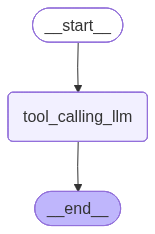

In [19]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

class MessagesState(TestMessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass
    
# Node
def tool_calling_llm(state: MessagesState):
    llm_invocation = llm_with_tools.invoke(state["messages"])
    print("tool_calls: %s" % llm_invocation.tool_calls)
    return {"messages": [llm_invocation]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

If we pass in `Hello!`, the LLM responds without any tool calls.

In [20]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

messages

tool_calls: []
================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I assist you today?


{'messages': [HumanMessage(content='Hello!', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 136, 'total_tokens': 169, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 18, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'cost': 3.01e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 3.01e-05, 'upstream_inference_prompt_cost': 1.36e-05, 'upstream_inference_completions_cost': 1.65e-05}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': None, 'id': 'gen-1770348431-ISPxb0kxbkSQ3zZ9MyNJ', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c30fd-460d-71f0-b79e-d1891428b3bd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 136, 'outp

The LLM chooses to use a tool when it determines that the input or task requires the functionality provided by that tool.

In [21]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

messages

tool_calls: [{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'chatcmpl-tool-ab3dafd444fc4712b5c51548b3fba314', 'type': 'tool_call'}]
================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (chatcmpl-tool-ab3dafd444fc4712b5c51548b3fba314)
 Call ID: chatcmpl-tool-ab3dafd444fc4712b5c51548b3fba314
  Args:
    a: 2
    b: 3


{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 140, 'total_tokens': 187, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 15, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'cost': 3.75e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 3.75e-05, 'upstream_inference_prompt_cost': 1.4e-05, 'upstream_inference_completions_cost': 2.35e-05}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': None, 'id': 'gen-1770348439-vvKkzEEFp0I6MSmSQi3R', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c30fd-658c-7672-8fca-1449bd1bac9d-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'chatcmpl-tool-ab3dafd444fc4712b5c